In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

In [113]:
df= pd.read_csv('/kaggle/input/datasets/mahad049/college-placement/placement-dataset.csv')
df.head()

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0


In [114]:
df.drop('city', axis=1, inplace=True)

In [115]:
df.isnull().sum()

cgpa         8
iq           4
placement    0
dtype: int64

In [116]:
df['iq']= df['iq'].fillna(df['iq'].median())
df['cgpa']= df['cgpa'].fillna(df['cgpa'].median())

In [117]:
X= df.drop(columns= 'placement', axis=1)
y=df['placement']

In [118]:
X.shape

(100, 2)

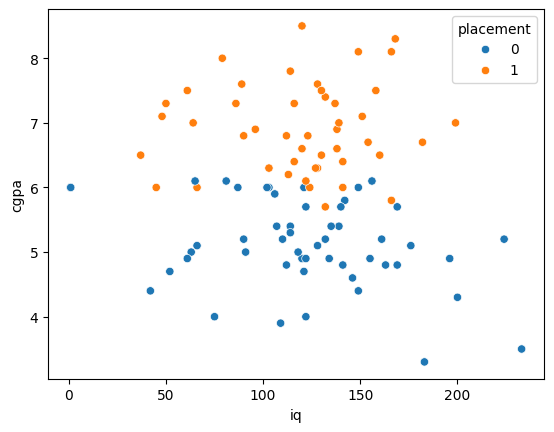

In [119]:
sns.scatterplot(x='iq', y='cgpa', hue='placement', data=df)
plt.show()

In [120]:
X= df.drop('placement', axis=1)
y=df['placement']

In [121]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 10)

In [122]:
model = Perceptron()
model.fit(X_train, y_train)

Perceptron()

In [123]:
print(model.score(X_train, y_train) * 100)
print(model.score(X_test, y_test) * 100)

47.5
40.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


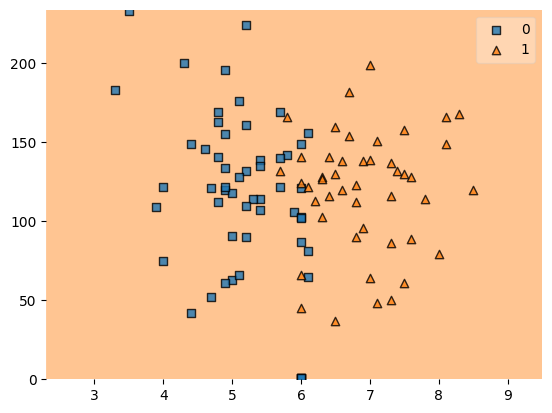

In [124]:
plot_decision_regions(X.to_numpy(), y.to_numpy(),clf= model)
plt.show()

> As we know, Perceptron not work perfectly for single layers. So, thats why it looks little bit overfitting